<a href="https://colab.research.google.com/github/JayadharsiniMathiyalagan/Fundamentals-of-Machine-Learning/blob/main/FOML_EXP_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Iris.csv')

Saving Iris.csv to Iris (1).csv


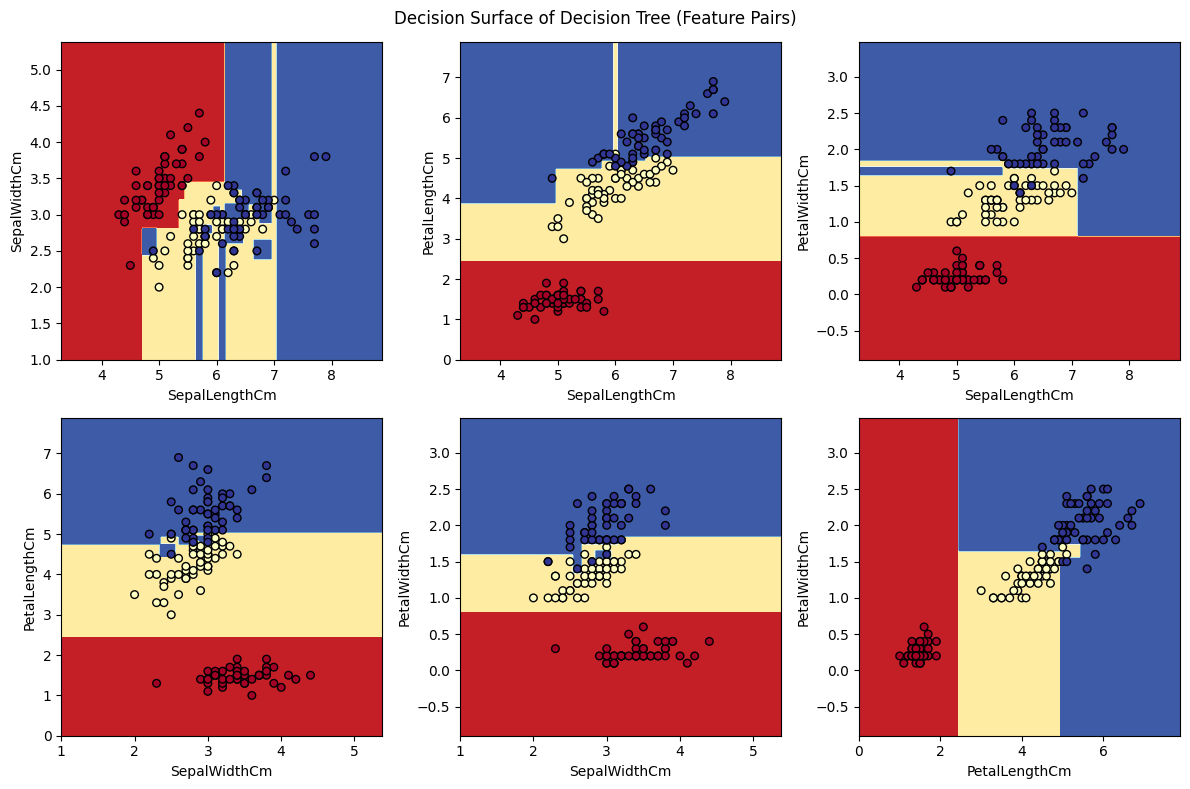

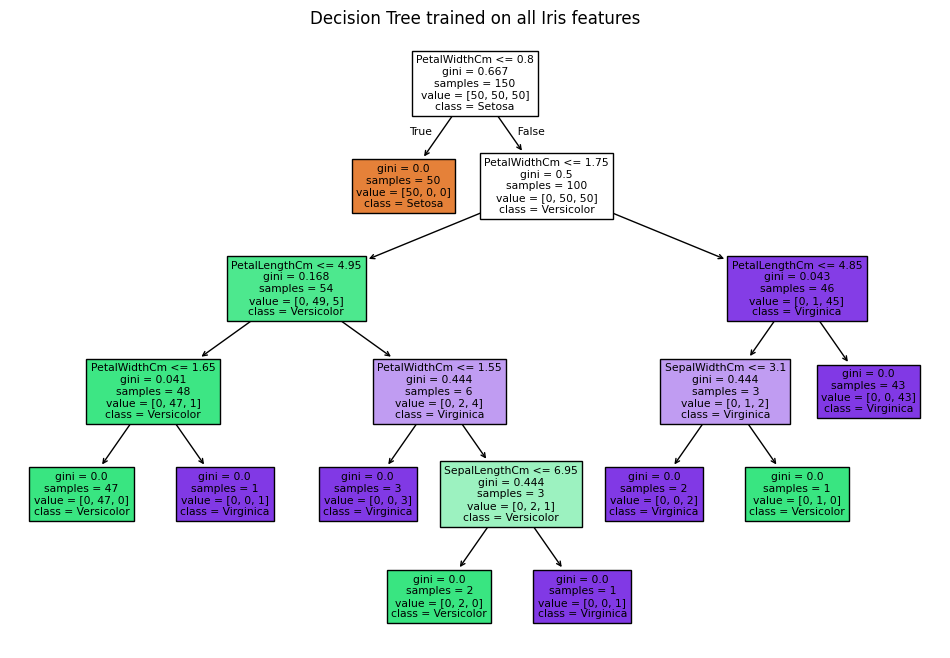

In [7]:
# ==============================
# STEP 2: Import Libraries
# ==============================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ==============================
# STEP 3: Prepare Data
# ==============================
# Drop Id column
df = df.drop(columns=['Id'], errors='ignore')

# Convert Species to numeric
df['Species'] = df['Species'].astype('category').cat.codes

# Features and target
X = df.drop(columns=['Species']).values
y = df['Species'].values

# ==============================
# STEP 4: Parameters
# ==============================
n_classes = 3
plot_colors = "ryb"
plot_step = 0.02

# ==============================
# STEP 5: Decision Boundary Plots (Feature Pairs)
# ==============================
plt.figure(figsize=(12,8))

pairs = [[0,1],[0,2],[0,3],[1,2],[1,3],[2,3]]

for pairidx, pair in enumerate(pairs):

    X_pair = X[:, pair]

    clf = DecisionTreeClassifier()
    clf.fit(X_pair, y)

    plt.subplot(2, 3, pairidx + 1)

    x_min, x_max = X_pair[:, 0].min() - 1, X_pair[:, 0].max() + 1
    y_min, y_max = X_pair[:, 1].min() - 1, X_pair[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, plot_step),
        np.arange(y_min, y_max, plot_step)
    )

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu)

    plt.xlabel(df.columns[pair[0]])
    plt.ylabel(df.columns[pair[1]])

    plt.scatter(X_pair[:, 0], X_pair[:, 1],
                c=y, cmap=plt.cm.RdYlBu,
                edgecolor='k', s=30)
print("\n")

plt.suptitle("Decision Surface of Decision Tree (Feature Pairs)")
plt.tight_layout()
plt.show()

# ==============================
# STEP 6: Plot Full Decision Tree
# ==============================
clf_full = DecisionTreeClassifier()
clf_full.fit(X, y)

plt.figure(figsize=(12,8))
plot_tree(clf_full,
          feature_names=df.columns[:-1],
          class_names=['Setosa','Versicolor','Virginica'],
          filled=True)
print("\n")
plt.title("Decision Tree trained on all Iris features")
plt.show()